# Statistical Analysis

## Target Variable

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv('../data/clean/processed_data.csv')

In [17]:
df['dependency_score'] = df[['ai_emotional_support_perception', 'ai_vs_human_interaction', 'ai_discomfort', 'ai_decision_support', 'ai_understanding',
                             'ai_vs_human_trust']].mean(axis=1)
bins = [1,2.5,4,5]
labels =['low', 'medium', 'high']
df['dependency_level'] = pd.cut(df['dependency_score'], bins=bins, labels=labels, include_lowest=True)
df.sample(5)

,age,career,ai_hours,ai_usage_frequency,ai_usage_type,ai_emotional_support_perception,ai_vs_human_interaction,ai_discomfort,ai_decision_support,ai_understanding,ai_vs_human_trust,social_interaction_frequency,seeks_help_from_others,uses_ai_for_emotional_support,follows_ai_advice,dependency_score,dependency_level
100,18-21,Ingeniería / STEM,1–2 horas,Varias veces al día,Estudio / tareas académicas,2,2,1,1,1,1,Frecuentemente,"Personas (amigos, familia)",False,False,1.333333,low
123,18-21,Ingeniería / STEM,Menos de 1 hora,Varias veces al día,Estudio / tareas académicas,1,1,2,2,1,2,Muy frecuentemente,"Personas (amigos, familia)",False,True,1.500000,low
4,18-21,Ingeniería / STEM,1–2 horas,Una vez al día,Estudio / tareas académicas,2,1,2,1,1,3,Muy frecuentemente,"Personas (amigos, familia)",True,False,1.666667,low
63,18-21,Ingeniería / STEM,Menos de 1 hora,Algunas veces a la semana,Estudio / tareas académicas,1,1,1,1,1,1,Muy frecuentemente,"Personas (amigos, familia)",False,False,1.000000,low
136,18-21,Ingeniería / STEM,Menos de 1 hora,Rara vez,Estudio / tareas académicas,1,1,1,3,1,3,Muy frecuentemente,"Personas (amigos, familia)",False,False,1.666667,low


Text(0, 0.5, 'Score')

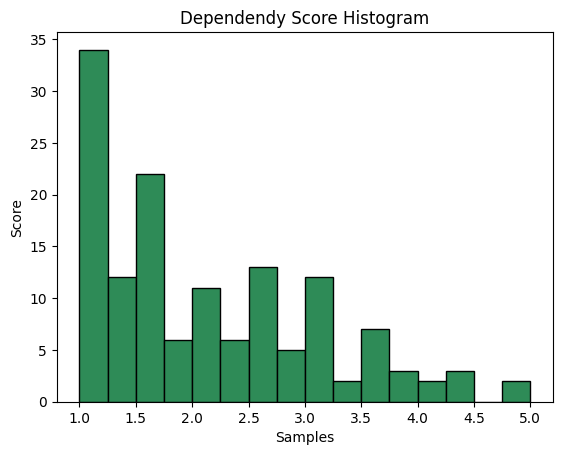

In [18]:
plt.hist(df['dependency_score'], bins=16, color='seagreen', edgecolor='black')
plt.title("Dependendy Score Histogram")
plt.xlabel("Samples")
plt.ylabel("Score")

In [19]:
df['dependency_level'].value_counts()

dependency_level
low       99
medium    34
high       7
Name: count, dtype: int64

## T-test

In [20]:
df['high_usage'] = df['ai_hours'].isin([
    '2–4 horas',
    'Más de 4 horas'
]).astype(int)
df['high_usage'].value_counts()

high_usage
0    109
1     31
Name: count, dtype: int64

In [21]:
df.sample(10)

,age,career,ai_hours,ai_usage_frequency,ai_usage_type,ai_emotional_support_perception,ai_vs_human_interaction,ai_discomfort,ai_decision_support,ai_understanding,ai_vs_human_trust,social_interaction_frequency,seeks_help_from_others,uses_ai_for_emotional_support,follows_ai_advice,dependency_score,dependency_level,high_usage
91,18-21,Otro,Menos de 1 hora,Algunas veces a la semana,Entretenimiento,2,1,1,2,2,1,Frecuentemente,"Personas (amigos, familia)",True,False,1.500000,low,0
42,18-21,Ingeniería / STEM,Menos de 1 hora,Algunas veces a la semana,Estudio / tareas académicas,1,1,1,1,1,1,Muy frecuentemente,"Personas (amigos, familia)",False,False,1.000000,low,0
134,18-21,Ingeniería / STEM,Más de 4 horas,Varias veces al día,Estudio / tareas académicas,4,4,1,3,5,4,Ocasionalmente,Ambos por igual,True,True,3.500000,medium,1
119,18-21,Ingeniería / STEM,1–2 horas,Algunas veces a la semana,Estudio / tareas académicas,2,1,2,1,3,2,Frecuentemente,"Personas (amigos, familia)",True,False,1.833333,low,0
7,18-21,Ingeniería / STEM,2–4 horas,Algunas veces a la semana,Estudio / tareas académicas,3,1,2,1,1,1,Frecuentemente,"Personas (amigos, familia)",True,False,1.500000,low,1
5,18-21,Ingeniería / STEM,1–2 horas,Algunas veces a la semana,Estudio / tareas académicas,3,4,1,4,3,4,Ocasionalmente,Ambos por igual,False,False,3.166667,medium,0
107,18-21,Ingeniería / STEM,1–2 horas,Varias veces al día,Estudio / tareas académicas,1,4,3,2,4,4,Muy frecuentemente,"Personas (amigos, familia)",True,True,3.000000,medium,0
19,18-21,Otro,1–2 horas,Una vez al día,Trabajo,3,5,2,3,5,4,Rara vez,Ambos por igual,True,True,3.666667,medium,0
58,18-21,Otro,2–4 horas,Algunas veces a la semana,Estudio / tareas académicas,1,1,1,1,1,1,Muy frecuentemente,"Personas (amigos, familia)",False,False,1.000000,low,1
0,18-21,Ingeniería / STEM,2–4 horas,Varias veces al día,Estudio / tareas académicas,2,4,4,4,2,3,Rara vez,"Personas (amigos, familia)",True,True,3.166667,medium,1


In [22]:
group_high = df[df['high_usage'] == 1]['dependency_score']
group_low  = df[df['high_usage'] == 0]['dependency_score']

In [23]:
n1 = len(group_high)
n2 = len(group_low)
mean1 = group_high.mean()
mean2 = group_low.mean()
var1 = group_high.var(ddof=1)
var2 = group_low.var(ddof=1)

In [24]:
se = np.sqrt((var1 / n1) + (var2 / n2))

In [25]:
t_stat = (mean1 - mean2) / se
df_num = (var1/n1 + var2/n2)**2
df_den = ((var1/n1)**2)/(n1-1) + ((var2/n2)**2)/(n2-1)
df_t = df_num / df_den
t_stat

np.float64(2.832136127827554)

In [26]:
from scipy.stats import t

p_value = 1 - t.cdf(t_stat, df_t)
p_value

np.float64(0.003488829305746677)

## Chi-squared test

In [27]:
table = pd.crosstab(
    df['social_interaction_frequency'],
    df['dependency_level']
)

print(table)

dependency_level              low  medium  high
social_interaction_frequency                   
Frecuentemente                 36       5     3
Muy frecuentemente             51      18     3
Ocasionalmente                  9       8     0
Rara vez                        3       3     1


In [28]:
# observed table
observed = table.values

# totals
row_totals = observed.sum(axis=1)
col_totals = observed.sum(axis=0)
N = observed.sum()

# expected table
expected = np.outer(row_totals, col_totals) / N

# chi-square statistic
chi2_stat = ((observed - expected)**2 / expected).sum()

print("Chi2:", chi2_stat)

Chi2: 12.407784536598628


In [29]:
r, c = observed.shape
chi_df = (r - 1) * (c - 1)

print("Degrees of freedom:", chi_df)

Degrees of freedom: 6


In [30]:
from scipy.stats import chi2

p_value = 1 - chi2.cdf(chi2_stat, chi_df)

print("p-value:", p_value)

p-value: 0.05346593692583379


In [31]:
df.to_csv('../data/clean/target_data.csv', index=0)